In [1]:
## 导入项目必须使用的包
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import spectral
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,recall_score,cohen_kappa_score,accuracy_score
from scipy.io import loadmat
import os
from tqdm.notebook import tqdm
%matplotlib inline

In [20]:
##定义实验设置
RANDOM_SEED=63466  ##随机种子
DATASET = 'IP'    ## PU  IP  SA 数据集的名称，根据这个选项进行,这里默认选择IP数据集
TRAIN_RATE = 0.3  ## 训练集的比例
VAL_RATE = 0.1    ## 验证集的比例
EPOCH = 20        ##训练迭代轮次
VAL_EPOCH = 5     ##interval of valuation
LR = 0.001        ##learning rate
WEIGHT_DECAY = 1e-6  
BATCH_SIZE = 256
DEVICE = 0  ##-1:CPU  0:cuda 0
N_PCA = 15  ## PCA降维的参数
PATCH_SIZE = 25 #划分高光谱patch的块大小 
SAVE_PATH = f"results\\{DATASET}"
if not os.path.isdir(SAVE_PATH):
    os.mkdir(SAVE_PATH)

In [4]:
## 设置随机种子确保实验可复制
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
def loadData(name):
    # 传入模型的名字，然后根据名字加载对应的数据
    data_path = os.path.join(os.getcwd(),'dataset')
    if name == 'IP':
        data = loadmat(os.path.join(data_path, 'Indian_pines_corrected.mat'))['indian_pines_corrected']
        labels = loadmat(os.path.join(data_path, 'Indian_pines_gt.mat'))['indian_pines_gt']
        class_name = [ "Alfalfa", "Corn-notill", "Corn-mintill","Corn", "Grass-pasture", 
                       "Grass-trees","Grass-pasture-mowed", "Hay-windrowed", "Oats","Soybean-notill", "Soybean-mintill", "Soybean-clean","Wheat", "Woods", "Buildings-Grass-Trees-Drives","Stone-Steel-Towers"]
    elif name == 'SA':
        data = loadmat(os.path.join(data_path, 'Salinas_corrected.mat'))['salinas_corrected']
        labels = loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']
        class_name = ['Brocoli_green_weeds_1','Brocoli_green_weeds_2','Fallow',
                        'Fallow_rough_plow','Fallow_smooth','Stubble','Celery','Grapes_untrained','Soil_vinyard_develop','Corn_senesced_green','Lettuce_romaine_4wk','Lettuce_romaine_5wk','Lettuce_romaine_6wk','Lettuce_romaine_7wk','Vinyard_untrained','Vinyard_vertical']
    elif name == 'PU':
        data = loadmat(os.path.join(data_path, 'PaviaU.mat'))['paviaU']
        labels = loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))['paviaU_gt']
        class_name = ['Asphalt', 'Meadows', 'Gravel', 'Trees','Painted metal sheets', 'Bare Soil', 
                      'Bitumen','Self-Blocking Bricks', 'Shadows']
    return data, labels, class_name


In [7]:
# 加载数据集，得到原始的数据和标签，查看类别的数量
data,label,class_name = loadData(DATASET)
NUM_CLASS = label.max() # 根据类别数字标签的最大值查看类别数量

d:\Program Files\miniconda\envs\torch\lib\site-packages\spectral\graphics\spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


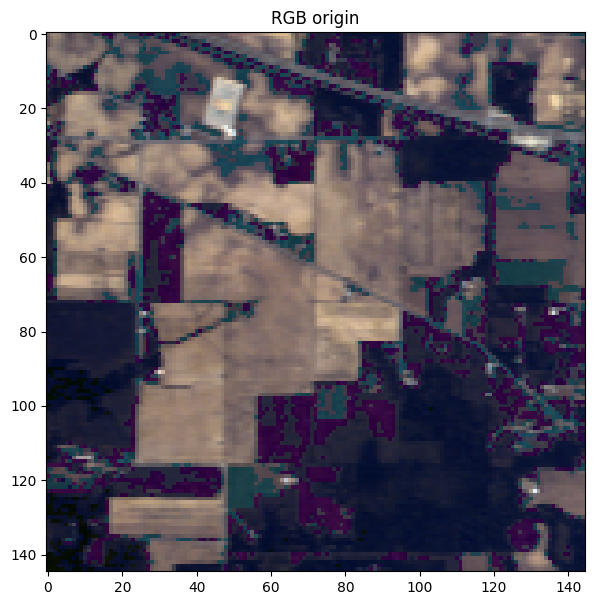

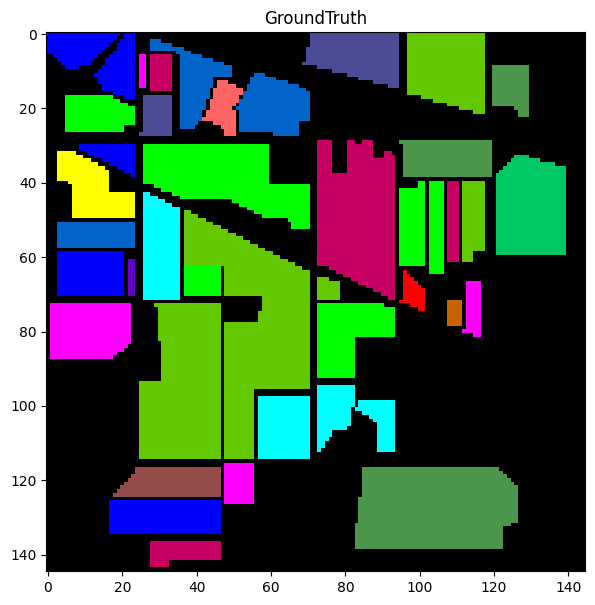

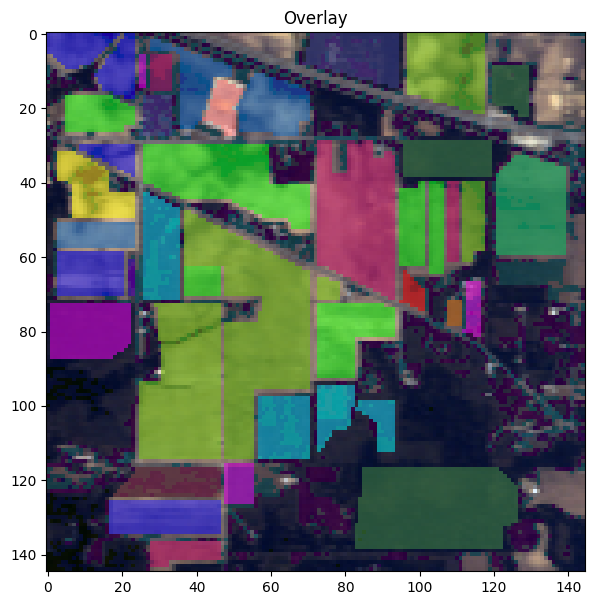

In [8]:
## 高光谱图像可视化
## 展示像素点以及对应标签
rgb_view=spectral.imshow(data,(30,20,10),classes=label,title='RGB origin',figsize=(7,7))
gt_view = spectral.imshow(classes=label, title='GroundTruth',figsize=(7,7)) 
view = spectral.imshow(data,(30,20,10),classes=label,figsize=(7,7))
view.set_display_mode('overlay')
view.class_alpha = 0.5
view.set_title('Overlay')
#将可视化图片保存起来
# spectral.save_rgb(f'results/{DATASET}_RGB_origin.jpg',data,(30,20,10))
# spectral.save_rgb(f'results/{DATASET}_gt.jpg',label,colors = spectral.spy_colors)

In [9]:
data.shape

(145, 145, 200)

In [10]:
def applyPCA(X, numComponents=15):
    """
        使用PCA降维处理高光谱图像,根据光谱数量设置
    """
    newX = np.reshape(X, (-1, X.shape[2])) # 由于高光谱数据是三维的所以要对数据进行reshape操作然后进行降维
    # (145, 145, 200)将光谱通道挤压在一起
    pca = PCA(n_components=numComponents, whiten=True)   ##PCA and normalization
    newX = pca.fit_transform(newX)
    newX = np.reshape(newX, (X.shape[0],X.shape[1], numComponents))
    return newX, pca

In [11]:
data,pca = applyPCA(data,N_PCA)
print("降维之后的数据shape",data.shape)

降维之后的数据shape (145, 145, 15)


In [12]:
def sample_gt(gt, train_rate):
    """
        为生成训练集和测试集划分标签
    Args:
        gt (ndarray): 标签
        train_rate (float): 训练集的比例
    Returns:
        train_gt(ndarray): 训练数据的类图
        test_gt(ndarray): 测试数据的类图
    """
    indices = np.nonzero(gt)  # 获取非零标签的位置，返回的是两个数组，分别为x和y坐标
    X = list(zip(*indices))  # 将非零位置结合成一个列表，格式为[(x1, y1), (x2, y2), ...]
    y = gt[indices].ravel()  # 获取对应位置的标签值，并展平为一维数组
    train_gt = np.zeros_like(gt)  # 创建一个与gt同样大小的全零数组，用于存储训练集标签
    test_gt = np.zeros_like(gt)   # 创建一个与gt同样大小的全零数组，用于存储测试集标签
    
    if train_rate > 1:  # 如果传入的训练集比例大于1，强制转换为整数
        train_rate = int(train_rate)
    
    # 根据提供的训练集比例，进行训练集和测试集的划分
    train_indices, test_indices = train_test_split(X, train_size=train_rate, stratify=y, random_state=100)
    train_indices = [t for t in zip(*train_indices)]  # 将训练集索引转换为列格式，即[[x1, x2, ...], [y1, y2, ...]]
    test_indices = [t for t in zip(*test_indices)]    # 同样处理测试集索引
    # 将训练集和测试集的标签填入对应的全零数组中
    train_gt[tuple(train_indices)] = gt[tuple(train_indices)]  # 用训练集的索引填充train_gt
    test_gt[tuple(test_indices)] = gt[tuple(test_indices)]     # 用测试集的索引填充test_gt
    return train_gt, test_gt  # 返回训练集和测试集的标签

In [13]:
train_gt, test_gt = sample_gt(label,TRAIN_RATE)
val_gt,test_gt = sample_gt(test_gt,VAL_RATE/(1-TRAIN_RATE))

  class   train_num  val_num   test_num   total   
    1         14        5         27        46    
    2        428       143       857       1428   
    3        249        83       498       830    
    4         71        24       142       237    
    5        145        48       290       483    
    6        219        73       438       730    
    7         8         3         17        28    
    8        143        48       287       478    
    9         6         2         12        20    
    10       292        97       583       972    
    11       736       245       1474      2455   
    12       178        59       356       593    
    13        62        20       123       205    
    14       379       127       759       1265   
    15       116        39       231       386    
    16        28        9         56        93    
  total      3074      1025      6150     10249   


d:\Program Files\miniconda\envs\torch\lib\site-packages\spectral\graphics\spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


ImageView object:
  Interpolation       :  <default>

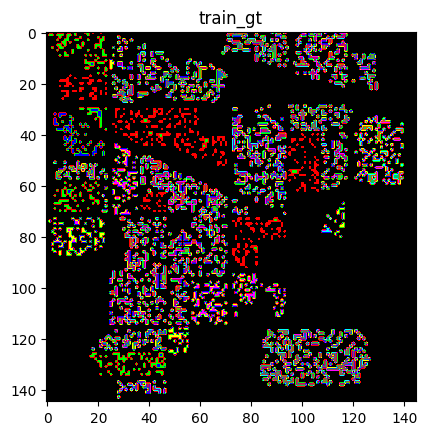

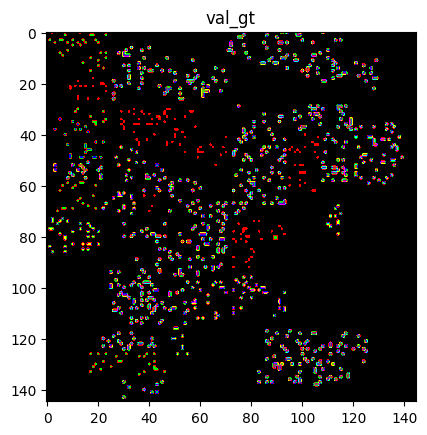

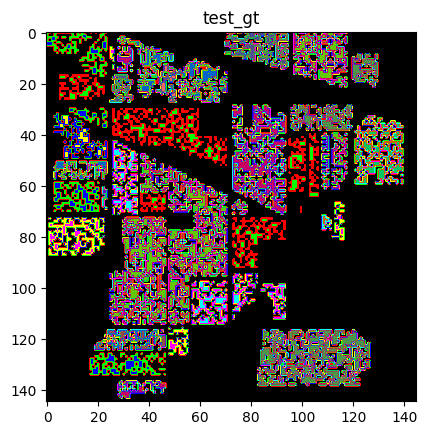

In [14]:
## 显示数据采样和划分信息
sample_report = f"{'class': ^10}{'train_num':^10}{'val_num': ^10}{'test_num': ^10}{'total': ^10}\n"
for i in np.unique(label):
    # 跳过背景，不对背景采样
    if i == 0: continue
    sample_report += f"{i: ^10}{(train_gt==i).sum(): ^10}{(val_gt==i).sum(): ^10}{(test_gt==i).sum(): ^10}{(label==i).sum(): ^10}\n"
sample_report += f"{'total': ^10}{np.count_nonzero(train_gt): ^10}{np.count_nonzero(val_gt): ^10}{np.count_nonzero(test_gt): ^10}{np.count_nonzero(label): ^10}"
print(sample_report)
spectral.imshow(classes=train_gt, title='train_gt')
spectral.imshow(classes=val_gt, title='val_gt')
spectral.imshow(classes=test_gt, title='test_gt')

In [15]:
import numpy as np
import torch
from torch.utils.data import Dataset

class PatchSet(Dataset):
    """ 从高光谱数据集生成3D补丁 """
    def __init__(self, data, gt, patch_size, is_pred=False):
        """
        Args:
            data: 3D hyperspectral image
            gt: 2D array of labels
            patch_size: int, size of the 3D patch
            is_pred: bool, create data without label for prediction (default False)
        """
        super(PatchSet, self).__init__()  # 调用父类Dataset的构造函数
        # 初始化参数
        self.is_pred = is_pred  # 是否为预测模式
        self.patch_size = patch_size  # 3D补丁的大小
        # 计算补丁半径，方便之后的填充
        p = self.patch_size // 2
        # 对数据进行填充，以便在生成补丁时不越界
        self.data = np.pad(data, ((p, p), (p, p), (0, 0)), 'constant', constant_values=0)  # 对高光谱数据在前两个维度进行填充，防止边界问题
        if is_pred:
            # 如果是预测模式，将标签全设为1，因为预测时不需要真实标签
            gt = np.ones_like(gt)
        # 对标签数据进行填充，防止边界问题
        self.label = np.pad(gt, (p, p), 'constant', constant_values=0)
        # 获取非零标签的位置 (即有效的样本位置)
        x_pos, y_pos = np.nonzero(gt)
        # 将位置索引加上填充后的偏移量，适应填充后的数据
        x_pos, y_pos = x_pos + p, y_pos + p  # 填充后的索引
        # 保存所有非零标签的索引，方便后续取样
        self.indices = np.array([(x, y) for x, y in zip(x_pos, y_pos)])
        # 如果不是预测模式，则对索引进行随机打乱，增加训练的随机性
        if not is_pred:
            np.random.shuffle(self.indices)

    def __len__(self):
        # 返回数据集的大小，即有效样本的数量
        return len(self.indices)

    def __getitem__(self, i):
        # 获取第i个样本的索引位置
        x, y = self.indices[i]
        # 根据索引位置计算补丁的左上角坐标
        x1, y1 = x - self.patch_size // 2, y - self.patch_size // 2
        # 计算补丁的右下角坐标
        x2, y2 = x1 + self.patch_size, y1 + self.patch_size
        # 从填充后的数据中提取出一个补丁
        data = self.data[x1:x2, y1:y2]
        # 获取对应位置的标签
        label = self.label[x, y]
        # 将数据转换为float32类型并调整通道顺序 (C, H, W)
        data = np.asarray(data, dtype='float32').transpose((2, 0, 1))
        # 将标签转换为int64类型
        label = np.asarray(label, dtype='int64')
        # 将numpy数组转换为PyTorch张量
        data = torch.from_numpy(data)
        label = torch.from_numpy(label)
        # 如果是预测模式，只返回数据，不返回标签
        if self.is_pred:
            return data
        else:
            return data, label


In [16]:
## 创建dataset
train_data = PatchSet(data, train_gt, PATCH_SIZE)
val_data = PatchSet(data, val_gt, PATCH_SIZE)
all_data = PatchSet(data, label, PATCH_SIZE,is_pred = True)
train_loader = DataLoader(train_data,BATCH_SIZE,shuffle= True)
val_loader = DataLoader(val_data,BATCH_SIZE,shuffle= True)
all_loader = DataLoader(all_data,BATCH_SIZE,shuffle= False)

In [17]:
d,g=train_data.__getitem__(0)
d.shape,g

(torch.Size([15, 25, 25]), tensor(11))

In [21]:
## Defination of HybridSN
class HybridSN(nn.Module):
    def __init__(self, in_chs, patch_size, class_nums):
        super().__init__()
        self.in_chs = in_chs
        self.patch_size = patch_size
        self.conv1 = nn.Sequential(nn.Conv3d(in_channels=1,out_channels=8,kernel_size=(7, 3, 3)),nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(nn.Conv3d(in_channels=8,out_channels=16,kernel_size=(5, 3, 3)),nn.ReLU(inplace=True))
        self.conv3 = nn.Sequential(nn.Conv3d(in_channels=16,out_channels=32,kernel_size=(3, 3, 3)),nn.ReLU(inplace=True))
        
        self.x1_shape = self.get_shape_after_3dconv() # 这里模拟三次卷积之后结果，然后记录
        # print(self.x1_shape)
        self.conv4 = nn.Sequential(nn.Conv2d(in_channels=self.x1_shape[1]*self.x1_shape[2],out_channels=64,kernel_size=(3, 3)),nn.ReLU(inplace=True))
        self.x2_shape = self.get_shape_after_2dconv()
        # print(self.x2_shape)
        self.dense1 = nn.Sequential(nn.Linear(self.x2_shape,256),nn.ReLU(inplace=True),nn.Dropout(p=0.4))
        
        self.dense2 = nn.Sequential(nn.Linear(256,128),nn.ReLU(inplace=True),nn.Dropout(p=0.4))
        
        self.dense3 = nn.Sequential(nn.Linear(128,class_nums))
    
    def get_shape_after_2dconv(self): # 获取2D卷积之后的shape
        x = torch.zeros((1, self.x1_shape[1]*self.x1_shape[2], self.x1_shape[3], self.x1_shape[4]))
        with torch.no_grad():
            x = self.conv4(x)
            print
        return x.shape[1]*x.shape[2]*x.shape[3]
    
    def get_shape_after_3dconv(self):
        x = torch.zeros((1, 1, self.in_chs, self.patch_size, self.patch_size))
        with torch.no_grad():
            x = self.conv1(x)
            x = self.conv2(x)
            x = self.conv3(x)
        return x.shape
    
    def forward(self, X):
        X = X.unsqueeze(1)
        x = self.conv1(X)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.shape[0],x.shape[1]*x.shape[2],x.shape[3],x.shape[4])
        # print(x.shape)
        x = self.conv4(x)
        x = x.contiguous().view(x.shape[0], -1)
        # print(x.shape)
        x = self.dense1(x)
        x = self.dense2(x)
        out = self.dense3(x)
        return out

net = HybridSN(N_PCA,PATCH_SIZE,class_nums=NUM_CLASS)
summary(net, input_size=(1,N_PCA,PATCH_SIZE,PATCH_SIZE),col_names=['num_params','kernel_size','mult_adds','input_size','output_size'],col_width=10,row_settings=['var_names'],depth=4)

Layer (type (var_name))                  Param #    Kernel Shape Mult-Adds  Input Shape Output Shape
HybridSN (HybridSN)                      --         --         --         [1, 15, 25, 25] [1, 16]
├─Sequential (conv1)                     --         --         --         [1, 1, 15, 25, 25] [1, 8, 9, 23, 23]
│    └─Conv3d (0)                        512        [7, 3, 3]  2,437,632  [1, 1, 15, 25, 25] [1, 8, 9, 23, 23]
│    └─ReLU (1)                          --         --         --         [1, 8, 9, 23, 23] [1, 8, 9, 23, 23]
├─Sequential (conv2)                     --         --         --         [1, 8, 9, 23, 23] [1, 16, 5, 21, 21]
│    └─Conv3d (0)                        5,776      [5, 3, 3]  12,736,080 [1, 8, 9, 23, 23] [1, 16, 5, 21, 21]
│    └─ReLU (1)                          --         --         --         [1, 16, 5, 21, 21] [1, 16, 5, 21, 21]
├─Sequential (conv3)                     --         --         --         [1, 16, 5, 21, 21] [1, 32, 3, 19, 19]
│    └─Conv3d (0)      

Training::   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

epoch 0/20 loss:0.011169585533241367  acc:0.14996746909564085


  0%|          | 0/13 [00:00<?, ?it/s]

epoch 1/20 loss:0.01003297432413641  acc:0.19030579050097593


...

epoch 18/20 loss:0.00314378533839559  acc:0.8532856213402733


  0%|          | 0/13 [00:00<?, ?it/s]

epoch 19/20 loss:0.0011025090969579582  acc:0.9268054651919323


  0%|          | 0/5 [00:00<?, ?it/s]

epoch 19/20  val_acc:0.9785365853658536
Stop in epoch 19


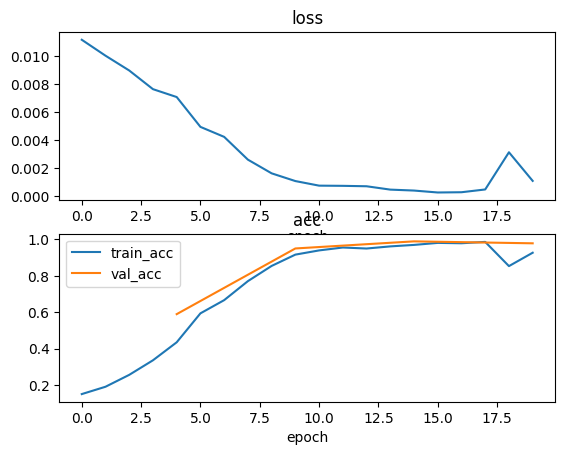

In [22]:
## training the model
device = torch.device(DEVICE if DEVICE>=0 and torch.cuda.is_available() else 'cpu')
loss_list = []
acc_list = []
val_acc_list = []
val_epoch_list = []

model = HybridSN(N_PCA,PATCH_SIZE,class_nums=NUM_CLASS)
model.to(device)
optimizer = torch.optim.Adam(model.parameters(),LR,weight_decay=WEIGHT_DECAY)
loss_func = nn.CrossEntropyLoss()
batch_num = len(train_loader)
train_num = train_loader.dataset.__len__()
val_num = val_loader.dataset.__len__()

fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)
try:
    for e in tqdm(range(EPOCH), desc="Training:"):
        model.train()
        avg_loss = 0.
        train_acc = 0
        for batch_idx, (data, target) in tqdm(enumerate(train_loader),total=batch_num):
            data,target = data.to(device),target.to(device)
            optimizer.zero_grad()
            out = model(data)
            target = target - 1  ## class 0 in out is class 1 in target
            loss = loss_func(out,target)
            loss.backward()
            optimizer.step()
            avg_loss += loss.item()
            _,pred = torch.max(out,dim=1)
            train_acc += (pred == target).sum().item()
        loss_list.append(avg_loss/train_num)
        acc_list.append(train_acc/train_num)
        print(f"epoch {e}/{EPOCH} loss:{loss_list[e]}  acc:{acc_list[e]}")
        ## valuation
        if (e+1)%VAL_EPOCH == 0 or (e+1)==EPOCH:
            val_acc =0
            model.eval()
            for batch_idx, (data, target) in tqdm(enumerate(val_loader),total=len(val_loader)):
                data,target = data.to(device),target.to(device)
                out = model(data)
                target = target - 1  ## class 0 in out is class 1 in target
                _,pred = torch.max(out,dim=1)
                val_acc += (pred == target).sum().item()
            val_acc_list.append(val_acc/val_num)
            val_epoch_list.append(e)
            print(f"epoch {e}/{EPOCH}  val_acc:{val_acc_list[-1]}")
            save_name = os.path.join(SAVE_PATH, f"epoch_{e}_acc_{val_acc_list[-1]:.4f}.pth")
            torch.save(model.state_dict(),save_name)
    ax1.plot(np.arange(e+1),loss_list)
    ax1.set_title('loss')
    ax1.set_xlabel('epoch')
    ax2.plot(np.arange(e+1),acc_list,label = 'train_acc')
    ax2.plot(val_epoch_list,val_acc_list,label = 'val_acc')
    ax2.set_title('acc')
    ax2.set_xlabel('epoch')
    ax2.legend()
except Exception as exc:
    print(exc)
finally: 
    print(f'Stop in epoch {e}')


In [23]:
## get best model path and del other models
def get_best_model(acc_list, epoch_list, save_path):
    """get best model path by valuation list

    Args:
        acc_list (list): list of valuation accuracy
        epoch_list (list): list of valuation epoch
        save_path (str): path of save dir

    Returns:
        best_model_path: path of best model
    """
    acc_list = np.array(acc_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argwhere(acc_list==np.max(acc_list))[-1].item()
    best_epoch = epoch_list[best_index]
    best_acc = acc_list[best_index]
    file_name = f"epoch_{best_epoch}_acc_{best_acc:.4f}.pth"
    best_model_path=os.path.join(save_path, file_name)
    print(f"best model:{file_name}")
    ##del save model except best model
    for f in os.listdir(save_path):
        if f[-3:]=='pth' and os.path.join(save_path,f)!=best_model_path:
            os.remove(os.path.join(save_path,f))
    return best_model_path

best model:epoch_14_acc_0.9893.pth


  0%|          | 0/83 [00:00<?, ?it/s]

d:\Program Files\miniconda\envs\torch\lib\site-packages\spectral\graphics\spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


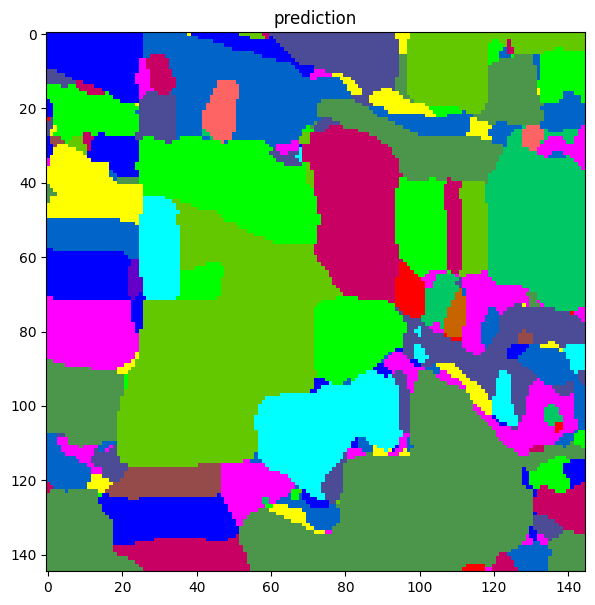

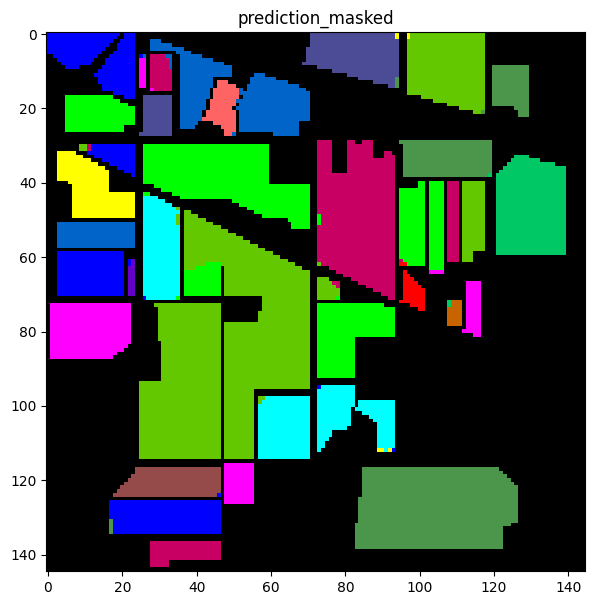

In [24]:
## inferring the whole image
##加载训练好的模型
best_model_path = get_best_model(val_acc_list,val_epoch_list,SAVE_PATH)
best_model = HybridSN(N_PCA,PATCH_SIZE,class_nums=NUM_CLASS)
best_model.load_state_dict(torch.load(best_model_path))
## 模型推理
best_model.to(device)
best_model.eval()
pred_map = []
for batch_idx, data in tqdm(enumerate(all_loader),total=len(all_loader)):
    data = data.to(device)
    target = best_model(data)
    _, pred = torch.max(target, dim = 1)
    pred_map += [np.array(pred.detach().cpu() + 1)]   ## class 0 in pred_map is class 1 in gt
pred_map = np.asarray(np.hstack(pred_map),dtype=np.uint8).reshape(label.shape[0],label.shape[1])
spectral.imshow(classes=pred_map,title='prediction',figsize=(7,7))
spectral.imshow(classes=pred_map*(label!=0),title='prediction_masked',figsize=(7,7))
spectral.save_rgb(os.path.join(SAVE_PATH,f"prediction.jpg"),pred_map,colors = spectral.spy_colors)
spectral.save_rgb(os.path.join(SAVE_PATH,f"prediction_masked.jpg"),pred_map*(label!=0),colors = spectral.spy_colors)

In [25]:
## classfication report
test_pred = pred_map[test_gt!=0]
test_true = test_gt[test_gt!=0]

OA = accuracy_score(test_true,test_pred)
AA = recall_score(test_true,test_pred,average='macro')
kappa = cohen_kappa_score(test_true,test_pred)
report_log = F"OA: {OA}\nAA: {AA}\nKappa: {kappa}\n"
report_log += classification_report(test_true,test_pred,target_names=class_name,digits=4)
print(report_log)
fp = open(os.path.join(SAVE_PATH,'classfication_report.txt'),'w+')
fp.writelines(report_log)
fp.close()

OA: 0.9908943089430894
AA: 0.9733551873770403
Kappa: 0.989617495135688
                              precision    recall  f1-score   support

                     Alfalfa     0.9310    1.0000    0.9643        27
                 Corn-notill     0.9895    0.9883    0.9889       857
                Corn-mintill     0.9899    0.9839    0.9869       498
                        Corn     0.9595    1.0000    0.9793       142
               Grass-pasture     0.9830    0.9966    0.9897       290
                 Grass-trees     1.0000    0.9749    0.9873       438
         Grass-pasture-mowed     1.0000    0.8824    0.9375        17
               Hay-windrowed     0.9931    1.0000    0.9965       287
                        Oats     1.0000    0.8333    0.9091        12
              Soybean-notill     0.9931    0.9863    0.9897       583
             Soybean-mintill     0.9932    0.9946    0.9939      1474
               Soybean-clean     0.9807    1.0000    0.9903       356
                  